# 72 — Step 1: place a known mask by pose

The plan, in one line:

    vibrations -> (x, y, theta) -> warp the KNOWN mask -> inpaint

This notebook builds the **middle arrow**: the geometric layer that turns a pose into a
placed object. No vibrations, no learning. If this layer is wrong everything downstream
inherits the error, so it is worth pinning down first.

The notebook is organised as four functions, in the order you'd call them:

| # | function | what it does |
|---|---|---|
| 0 | `get_reference(sample_id)` | the template: object image + mask, cropped to the object |
| 1 | `estimate_pose_params(ref)` | scan scale x theta over the whole dataset -> the constants |
| 2 | `predict(ref, row, col, theta, scale)` | place the template -> predicted image + mask |
| 3 | `viz(pred, ref, truth)` | the 2x3 comparison grid |

Set `SAMPLE_ID` (env var or the constant below) and everything else follows from it.

**Scope:** one object — the `purple-cube` layout. Scale is a fitted constant, not a
prediction. Theta is fitted too, and section 1 shows what it actually measures (not rotation).

In [1]:
import os, sys; sys.path.insert(0, "..")
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import affine_transform

from utils.io_utils import load_metadata
from utils.metrics import center_of_mass

EXP = Path("../experiments/31_07_2026_gastronorm_exp1/samples")
LAYOUT = "purple-cube"          # the one-cube case

# The one knob. Everything downstream is derived from it.
SAMPLE_ID = os.environ.get("SAMPLE_ID", "000313")   # position 40, near box centre
REF_ID    = os.environ.get("REF_ID", "000041")      # the sample the template comes from

print(f"SAMPLE_ID = {SAMPLE_ID}   (target)")
print(f"REF_ID    = {REF_ID}   (reference/template)")

SAMPLE_ID = 000313   (target)
REF_ID    = 000041   (reference/template)


## The pose convention

Everything is **(row, col)** — the order `center_of_mass` returns and the viz dashboard
uses. A pose is a 3x3 homogeneous matrix acting on `(row, col, 1)`:

    M = [[ s*cos t, -s*sin t,  r0 ],
         [ s*sin t,  s*cos t,  c0 ],
         [ 0,        0,         1 ]]

A **similarity transform**: 4 DOF (r0, c0, theta, scale). Not a general affine — letting
shear in would raise IoU while destroying the parameters' physical meaning.

In [2]:
def pose_matrix(row: float, col: float, theta: float = 0.0, scale: float = 1.0) -> np.ndarray:
    """Similarity transform as a 3x3 homogeneous matrix acting on (row, col, 1)."""
    ct, st = np.cos(theta), np.sin(theta)
    M = np.eye(3)
    M[:2, :2] = scale * np.array([[ct, -st], [st, ct]])
    M[:2, 2] = [row, col]
    return M


def pose_params(M: np.ndarray) -> dict:
    """Inverse of pose_matrix: read (row, col, theta, scale) back out."""
    return {"row": M[0, 2], "col": M[1, 2],
            "theta": np.arctan2(M[1, 0], M[0, 0]),
            "scale": float(np.sqrt(np.linalg.det(M[:2, :2])))}


def warp(template: np.ndarray, M: np.ndarray, out_shape, origin=(0, 0), order: int = 1):
    """Warp `template` by pose `M`, rendering into a canvas whose top-left corner sits at
    `origin` in full-image coordinates.

    The template is anchored at its own centroid, so M's translation reads as "put the
    object's centroid here". `origin` is what makes the window trick work: rendering into
    a small box around the object is ~15x faster than painting the whole frame and gives
    bit-identical results (section 1 relies on this).

    scipy's affine_transform maps OUTPUT -> INPUT, so it gets the inverse of the chain.
    """
    tr, tc = center_of_mass(template)
    C = np.eye(3); C[:2, 2] = [-tr, -tc]            # template px -> centroid-centred
    T = np.eye(3); T[:2, 2] = [-origin[0], -origin[1]]   # full-image px -> window px
    inv = np.linalg.inv(T @ M @ C)
    return affine_transform(template, inv[:2, :2], offset=inv[:2, 2],
                            output_shape=out_shape, order=order, mode="constant", cval=0.0)


def iou(a: np.ndarray, b: np.ndarray, thresh: float = 0.5) -> float:
    a, b = a > thresh, b > thresh
    union = (a | b).sum()
    return float((a & b).sum() / union) if union else 0.0

## 0. `get_reference` — the template

The reference is the object's appearance in a neutral frame: its silhouette **and** its
pixels, both cropped tight to the object. The crop is what makes this a *template* rather
than "a photo that happens to contain a cube" — it separates the object from however much
empty box surrounded it in that particular sample.

The pad keeps a zero border so bilinear interpolation always has something to blend
against at the silhouette edge.

reference 000041: mask (119, 108), photo (119, 108, 3), area 10662 px
border sums (must all be 0): 0.0 0.0 0.0 0.0


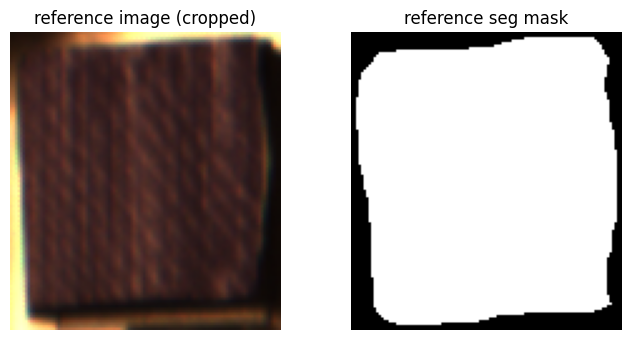

In [3]:
def sample_dir(sample_id: str) -> Path:
    d = EXP / sample_id
    if not d.exists(): raise FileNotFoundError(f"no sample {sample_id} under {EXP}")
    return d


def load_mask(sample_id: str) -> np.ndarray:
    """Full-resolution binary segmentation mask, (H, W)."""
    return np.load(sample_dir(sample_id) / "image" / "03_smask.npy")


def load_photo(sample_id: str) -> np.ndarray:
    """Overhead photo, already cropped to the box at the mask's resolution."""
    return np.array(Image.open(sample_dir(sample_id) / "image" / "02_cropped_overhead.png"))


def get_reference(sample_id: str = REF_ID, pad: int = 2) -> dict:
    """The template: the object's mask and pixels, both cropped to the object itself.

    Returns a dict with
        mask   (h, w) float32 silhouette, zero border
        photo  (h, w, 3) uint8 the object's actual pixels, same crop
        bbox   (r0, c0) where the crop came from, for provenance
    """
    mask, photo = load_mask(sample_id), load_photo(sample_id)
    rows, cols = np.nonzero(mask)
    if len(rows) == 0: raise ValueError(f"sample {sample_id} has an empty mask")
    r0, c0 = max(rows.min() - pad, 0), max(cols.min() - pad, 0)
    r1, c1 = rows.max() + 1 + pad, cols.max() + 1 + pad
    return {"id": sample_id,
            "mask": mask[r0:r1, c0:c1].astype(np.float32),
            "photo": photo[r0:r1, c0:c1],
            "bbox": (r0, c0)}


ref = get_reference()
print(f"reference {ref['id']}: mask {ref['mask'].shape}, photo {ref['photo'].shape}, "
      f"area {int(ref['mask'].sum())} px")
print("border sums (must all be 0):",
      ref["mask"][0].sum(), ref["mask"][-1].sum(), ref["mask"][:, 0].sum(), ref["mask"][:, -1].sum())

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(ref["photo"]);                axes[0].set_title("reference image (cropped)")
axes[1].imshow(ref["mask"], cmap="gray");    axes[1].set_title("reference seg mask")
for a in axes: a.axis("off")
plt.tight_layout()

## 1. `estimate_pose_params` — fit scale and theta over the whole dataset

Scale and theta are **not** predicted per sample: the camera and box are fixed, so they
should be calibrated once and hardcoded. This section fits them by brute force over every
distinct position and reports the constants.

**The window trick.** A naive scan renders the full 1110x1337 frame for every candidate —
1.48M pixels to move a ~110px cube, 99% of them guaranteed zero. Rendering into a bbox
window around the object instead is **~15x faster** for bit-identical IoU. That is what
makes a full scale x theta grid (36,890 warps) take ~20 seconds instead of minutes.

In [4]:
def one_cube_ids(layout: str = LAYOUT) -> list[str]:
    """Sample ids for the single-object layout."""
    needle = f'"layout": "{layout}"'
    return sorted(d.name for d in EXP.iterdir()
                  if (d / "metadata.jsonl").exists() and needle in (d / "metadata.jsonl").read_text())


def by_position(ids: list[str]) -> dict[int, str]:
    """One representative sample per distinct position_id."""
    out = {}
    for sid in ids:
        out.setdefault(load_metadata(sample_dir(sid) / "metadata.jsonl")["position_id"], sid)
    return out


def _window(mask, pad=60):
    """A slice around the object, plus its origin, so warps skip the empty 99%."""
    rows, cols = np.nonzero(mask)
    r0, c0 = max(rows.min() - pad, 0), max(cols.min() - pad, 0)
    r1, c1 = min(rows.max() + pad, mask.shape[0]), min(cols.max() + pad, mask.shape[1])
    return (slice(r0, r1), slice(c0, c1)), (r0, c0)


def fit_one(ref_mask, mask, scales, thetas):
    """Best (iou, scale, theta) for a single mask. Translation is measured, not searched --
    the centroid is the anchor, so it is known exactly."""
    row, col = center_of_mass(mask)
    sl, origin = _window(mask)
    target = mask[sl]
    best = (-1.0, 1.0, 0.0)
    for s in scales:
        for t in thetas:
            v = iou(warp(ref_mask, pose_matrix(row, col, t, s), target.shape, origin), target)
            if v > best[0]: best = (v, s, t)
    return best


def estimate_pose_params(ref: dict, scales=None, thetas=None, verbose: bool = True) -> dict:
    """Fit scale and theta across every distinct position in the dataset.

    Returns the constants to hardcode, plus the per-position fits so the spread is visible.
    """
    scales = np.round(np.arange(0.96, 1.13, 0.01), 3) if scales is None else scales
    thetas = np.deg2rad(np.arange(-15, 15.1, 1.0)) if thetas is None else thetas

    positions = by_position(one_cube_ids())
    fits = {}
    for pid, sid in sorted(positions.items()):
        fits[pid] = fit_one(ref["mask"], load_mask(sid), scales, thetas)

    ious   = np.array([f[0] for f in fits.values()])
    best_s = np.array([f[1] for f in fits.values()])
    best_t = np.rad2deg([f[2] for f in fits.values()])

    # one constant for the whole box: the scale maximising MEAN iou, not the mean of the
    # per-position argmaxes -- those are different numbers and the first is what we deploy
    curve = {}
    for s in scales:
        curve[s] = float(np.mean([
            iou(warp(ref["mask"], pose_matrix(*center_of_mass(m), 0.0, s),
                     m[_window(m)[0]].shape, _window(m)[1]), m[_window(m)[0]])
            for m in (load_mask(sid) for sid in positions.values())]))
    scale = max(curve, key=curve.get)

    out = {"scale": float(scale), "theta": 0.0, "curve": curve, "fits": fits,
           "n_positions": len(positions),
           "per_position_scale": best_s, "per_position_theta_deg": best_t,
           "per_position_iou": ious}
    if verbose:
        print(f"{len(positions)} distinct positions, "
              f"{len(scales)} scales x {len(thetas)} thetas = "
              f"{len(positions)*len(scales)*len(thetas)} warps\n")
        print(f"  scale : best constant {scale}  (mean IoU {curve[scale]:.4f})")
        print(f"          per-position argmax {best_s.mean():.3f} +/- {best_s.std():.3f} "
              f"[{best_s.min():.2f}, {best_s.max():.2f}]")
        print(f"  theta : per-position argmax {best_t.mean():+.2f} +/- {best_t.std():.2f} deg "
              f"[{best_t.min():+.1f}, {best_t.max():+.1f}]")
        print(f"          -> NOT centred on 0. This is perspective being absorbed,")
        print(f"             not rotation -- see the note below. We still deploy theta=0.")
        print(f"\n  free-fit mean IoU {ious.mean():.4f}  (constant-scale, theta=0: {curve[scale]:.4f})")
    return out


import time
_t0 = time.time()
params = estimate_pose_params(ref)
print(f"\n[{time.time() - _t0:.1f}s]")

SCALE, THETA = params["scale"], params["theta"]

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


70 distinct positions, 17 scales x 31 thetas = 36890 warps

  scale : best constant 1.03  (mean IoU 0.9161)
          per-position argmax 1.029 +/- 0.028 [0.96, 1.08]
  theta : per-position argmax -4.39 +/- 2.05 deg [-9.0, +0.0]
          -> NOT centred on 0. This is perspective being absorbed,
             not rotation -- see the note below. We still deploy theta=0.

  free-fit mean IoU 0.9519  (constant-scale, theta=0: 0.9161)

[30.4s]


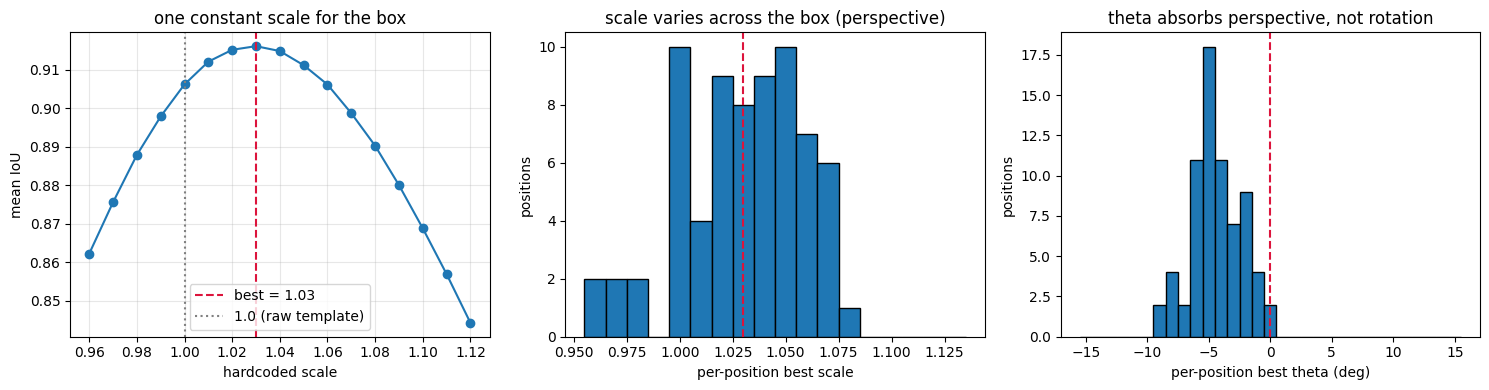

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(params["curve"]), list(params["curve"].values()), "o-")
axes[0].axvline(SCALE, ls="--", c="crimson", label=f"best = {SCALE}")
axes[0].axvline(1.0, ls=":", c="gray", label="1.0 (raw template)")
axes[0].set_xlabel("hardcoded scale"); axes[0].set_ylabel("mean IoU")
axes[0].set_title("one constant scale for the box"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].hist(params["per_position_scale"], bins=np.arange(0.955, 1.135, 0.01), edgecolor="k")
axes[1].axvline(SCALE, ls="--", c="crimson")
axes[1].set_xlabel("per-position best scale"); axes[1].set_ylabel("positions")
axes[1].set_title("scale varies across the box (perspective)")

axes[2].hist(params["per_position_theta_deg"], bins=np.arange(-15.5, 16.5, 1.0), edgecolor="k")
axes[2].axvline(0, ls="--", c="crimson")
axes[2].set_xlabel("per-position best theta (deg)"); axes[2].set_ylabel("positions")
axes[2].set_title("theta absorbs perspective, not rotation")
plt.tight_layout()

### What the fit says

**Scale is a compromise, and the residual is perspective.** The per-position histogram is
not a spike — the cube's apparent size genuinely varies across the box, because an overhead
camera sees the *sides* of off-centre cubes and only the top of centred ones. One constant
cannot represent a spatial trend, which is why the curve is flat-topped. Fixing it properly
means a homography, not a better constant.

**Theta does *not* come out at 0 — and that is a finding, not a bug.** The per-position
argmax sits at about **-4.4 deg +/- 2.1**, entirely negative, with no mass on the positive
side. Noise would straddle zero; this does not.

It is not rotation either. Checked directly: the fitted theta correlates only **0.52** with
the true difference in principal-axis angle between target and reference, and the worst case
wants -8 deg where the real difference is -35 deg. Meanwhile the reference fitted against
*itself* gives exactly 0.0 at IoU 1.0.

What theta is actually doing is **absorbing the perspective mismatch**. An off-centre cube
shows its sides, so its true silhouette is a slightly sheared trapezoid rather than the
template's square. A similarity transform has no shear parameter, and rotation is the
nearest thing to one, so the optimiser spends theta on it. The bias is uniformly negative
because the reference sits in one corner of the box and every other position is displaced
in a consistent direction from it.

**So we deploy `theta = 0`**, and treat the fitted values as a diagnostic for perspective
rather than a pose estimate. Letting theta soak up a projective effect would buy IoU while
making the parameter meaningless — the same objection that rules out a general affine.

Two things follow for anyone training on this. A cube is **4-fold symmetric**, so its
silhouette at theta and theta+90 deg is identical and a binary mask carries no information
distinguishing them: a rotation head supervised by a mask loss has no gradient to learn
from. And even the signal that *is* there is contaminated by perspective. Theta becomes a
real target only with an asymmetric object and a rectified camera.

fitted theta   : -4.39 +/- 2.05 deg
true delta     : +7.65 +/- 10.35 deg
correlation    : 0.303

-> does NOT track real rotation. The fit is absorbing perspective shear, not measuring pose.


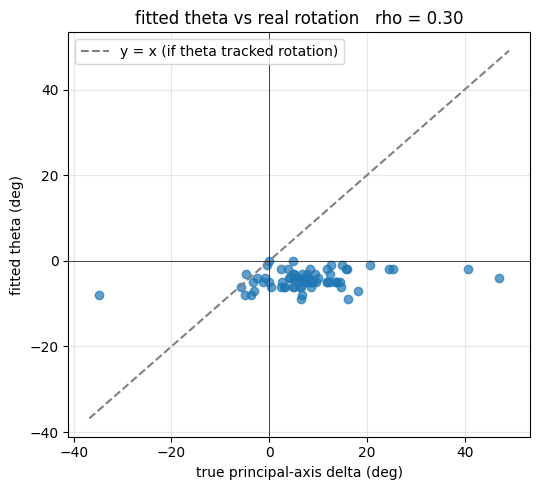

In [6]:
def principal_angle(mask: np.ndarray) -> float:
    """Orientation of a mask's principal axis in degrees, folded to (-45, 45]."""
    r, c = np.nonzero(mask)
    cov = np.cov(np.stack([r - r.mean(), c - c.mean()]))
    _, vecs = np.linalg.eigh(cov)
    return ((np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1])) + 45) % 90) - 45


# Does the fitted theta track REAL rotation? Compare it against the true difference in
# principal-axis angle between each target and the reference.
positions_ = by_position(one_cube_ids())
ref_angle = principal_angle(load_mask(ref["id"]))
true_delta = np.array([principal_angle(load_mask(sid)) - ref_angle
                       for _, sid in sorted(positions_.items())])
fitted = params["per_position_theta_deg"]

rho = np.corrcoef(fitted, true_delta)[0, 1]
print(f"fitted theta   : {fitted.mean():+.2f} +/- {fitted.std():.2f} deg")
print(f"true delta     : {true_delta.mean():+.2f} +/- {true_delta.std():.2f} deg")
print(f"correlation    : {rho:.3f}")
print(f"\n-> {'tracks' if abs(rho) > 0.9 else 'does NOT track'} real rotation. "
      f"The fit is absorbing perspective shear, not measuring pose.")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(true_delta, fitted, alpha=.7)
lim = [min(true_delta.min(), fitted.min()) - 2, max(true_delta.max(), fitted.max()) + 2]
ax.plot(lim, lim, ls="--", c="gray", label="y = x (if theta tracked rotation)")
ax.axhline(0, lw=.5, c="k"); ax.axvline(0, lw=.5, c="k")
ax.set_xlabel("true principal-axis delta (deg)"); ax.set_ylabel("fitted theta (deg)")
ax.set_title(f"fitted theta vs real rotation   rho = {rho:.2f}")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()

## 2. `predict` — place the template at a pose

The function the whole notebook is for. Given the reference and a pose, warp **both** the
template mask and the template's pixels by the same matrix. The image prediction is a real
composite, not a stand-in — it is the reference object's own pixels, relocated.

The predicted image lands on black: compositing onto a background is the inpainting
stage's job, and faking it here would misrepresent what this layer does.

In [7]:
def predict(ref: dict, row: float, col: float, theta: float = None, scale: float = None,
            out_shape: tuple[int, int] = (1110, 1337)) -> dict:
    """Place the known object at a predicted pose.

    Returns {mask, photo, M, params} -- mask is soft (float in [0,1]); keep it that way if
    a mask loss will ever be backpropagated through this, since the soft edge is where the
    gradient with respect to pose lives.
    """
    theta = THETA if theta is None else theta
    scale = SCALE if scale is None else scale
    M = pose_matrix(row, col, theta, scale)
    mask = warp(ref["mask"], M, out_shape)
    photo = np.stack([warp(ref["photo"][..., k].astype(np.float32), M, out_shape)
                      for k in range(3)], -1).clip(0, 255).astype(np.uint8)
    return {"mask": mask, "photo": photo, "M": M, "params": pose_params(M)}


# drive it from SAMPLE_ID: measure the target's centroid, predict, compare
truth_mask, truth_photo = load_mask(SAMPLE_ID), load_photo(SAMPLE_ID)
row, col = center_of_mass(truth_mask)
pred = predict(ref, row, col, out_shape=truth_mask.shape)

print(f"target {SAMPLE_ID}   reference {ref['id']}")
print(f"\n(row, col) = ({row:.2f}, {col:.2f})   full-res px")
print(f"normalized = ({row / (truth_mask.shape[0] - 1):.4f}, {col / (truth_mask.shape[1] - 1):.4f})")
print(f"theta = {THETA:.4f} rad   scale = {SCALE}")
print("\npose matrix M (acts on [row, col, 1]):")
for r_ in pred["M"]: print("   [" + "  ".join(f"{v:9.4f}" for v in r_) + "]")
print(f"\nrecovered from M: { {k: round(v, 4) for k, v in pred['params'].items()} }")
print(f"\nIoU(pred, truth) = {iou(pred['mask'], truth_mask):.4f}")

target 000313   reference 000041

(row, col) = (502.60, 720.72)   full-res px
normalized = (0.4532, 0.5395)
theta = 0.0000 rad   scale = 1.03

pose matrix M (acts on [row, col, 1]):
   [   1.0300    -0.0000   502.5958]
   [   0.0000     1.0300   720.7242]
   [   0.0000     0.0000     1.0000]

recovered from M: {'row': 502.5958, 'col': 720.7242, 'theta': 0.0, 'scale': 1.03}

IoU(pred, truth) = 0.9444


## 3. `viz` — the 2x3 grid

Two rows (image / segmentation) by three columns (reference / ground truth / prediction).

The reference column is cropped to the object — it is a template, and showing it at full
frame would waste the panel on empty box. The other two columns are at the full 1110x1337
frame, because the cube is under 1% of it and a zoomed crop flatters any placement.

The prediction panel carries the predicted silhouette as a **green outline** so it can be
read against the object underneath.

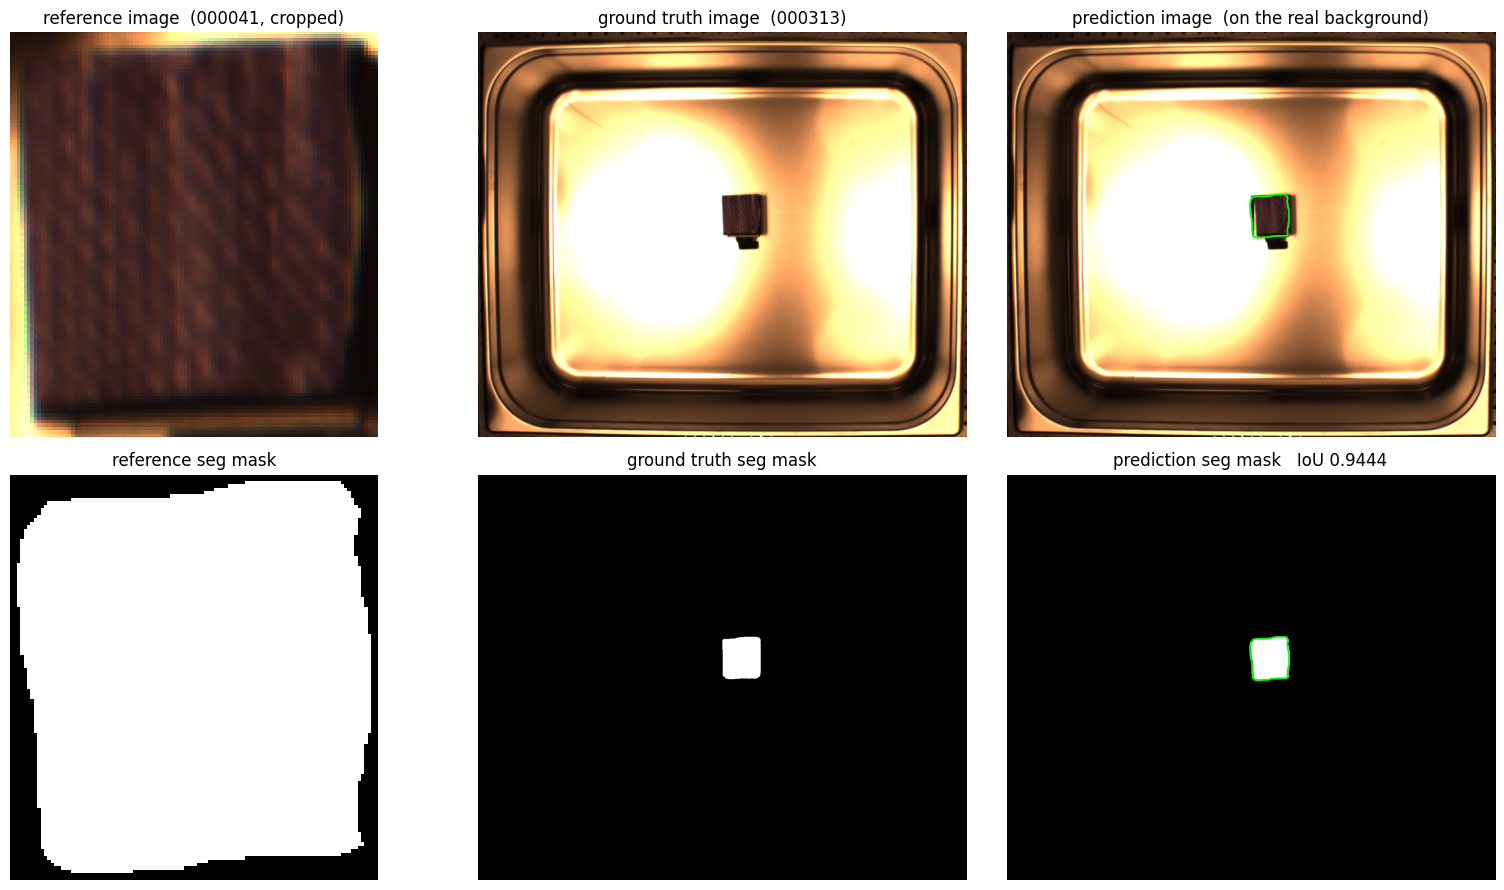

In [8]:
def composite(pred: dict, background: np.ndarray) -> np.ndarray:
    """Paste the predicted object onto a background, feathered by the soft mask.

    NOTE what this is and is not. The object is predicted; the background is the ground
    truth photo, which a real pipeline would not have -- filling it is the inpainting
    stage's job. So this is a fair view of *placement* against the scene, but the
    background is borrowed, not generated.
    """
    alpha = np.clip(pred["mask"], 0, 1)[..., None]
    return (alpha * pred["photo"] + (1 - alpha) * background).astype(np.uint8)


def viz(pred: dict, ref: dict, truth_photo: np.ndarray, truth_mask: np.ndarray,
        sample_id: str = "", figsize=(16, 9)):
    """2x3 grid: rows = image / seg mask, cols = reference / ground truth / prediction."""
    score = iou(pred["mask"], truth_mask)
    fig, axes = plt.subplots(2, 3, figsize=figsize)

    # column 0 -- reference, cropped to the object
    axes[0, 0].imshow(ref["photo"])
    axes[0, 0].set_title(f"reference image  ({ref['id']}, cropped)")
    axes[1, 0].imshow(ref["mask"], cmap="gray")
    axes[1, 0].set_title("reference seg mask")

    # column 1 -- ground truth, full frame
    axes[0, 1].imshow(truth_photo)
    axes[0, 1].set_title(f"ground truth image  ({sample_id})")
    axes[1, 1].imshow(truth_mask, cmap="gray")
    axes[1, 1].set_title("ground truth seg mask")

    # column 2 -- prediction, composited onto the real background so it is comparable
    # to column 1 rather than floating on black
    axes[0, 2].imshow(composite(pred, truth_photo))
    axes[0, 2].contour(pred["mask"], levels=[0.5], colors="lime", linewidths=1.2)
    axes[0, 2].set_title("prediction image  (on the real background)")
    axes[1, 2].imshow(pred["mask"], cmap="gray")
    axes[1, 2].contour(pred["mask"], levels=[0.5], colors="lime", linewidths=1.2)
    axes[1, 2].set_title(f"prediction seg mask   IoU {score:.4f}")

    for a in axes.ravel(): a.axis("off")
    plt.tight_layout()
    return fig


viz(pred, ref, truth_photo, truth_mask, SAMPLE_ID);

### Zoomed in

At full frame the cube is under 1% of the image, so the disagreement is invisible. Zoomed,
the residual from section 1 is plain: the true silhouette (red) is taller than the placed
template (green), because the camera sees the cube's side and the template is a square
seen from a different position.

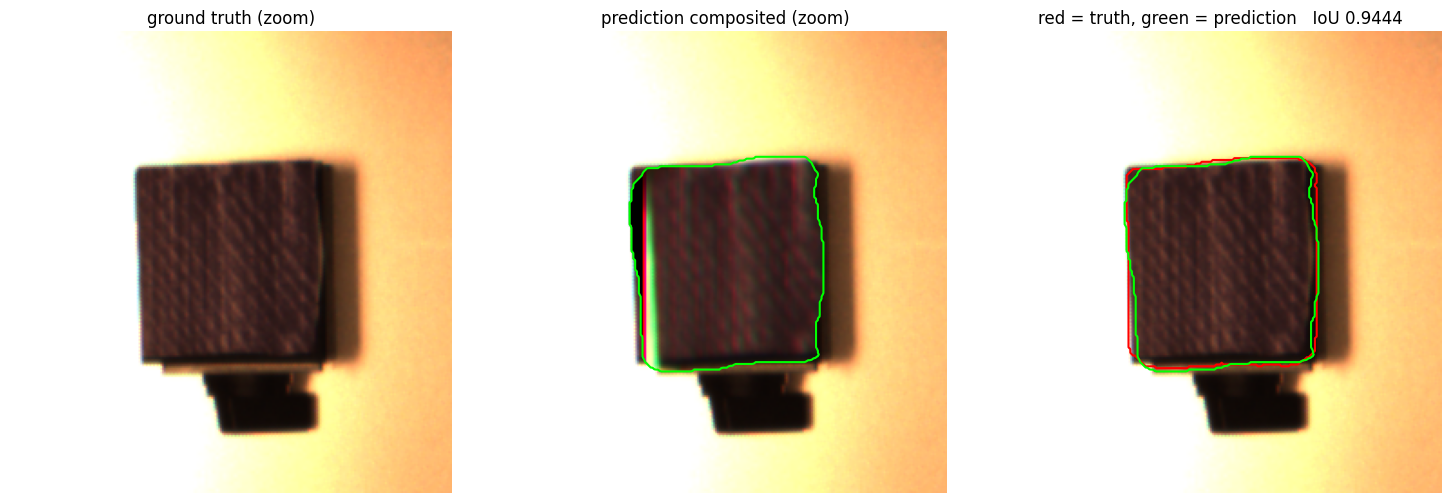

In [9]:
# zoom in on the object, where the residual actually lives
score = iou(pred["mask"], truth_mask)
rr, cc = np.nonzero(truth_mask)
pad = 70
sl = (slice(max(rr.min() - pad, 0), rr.max() + pad),
      slice(max(cc.min() - pad, 0), cc.max() + pad))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(truth_photo[sl])
axes[0].set_title("ground truth (zoom)")

axes[1].imshow(composite(pred, truth_photo)[sl])
axes[1].contour(pred["mask"][sl], levels=[0.5], colors="lime", linewidths=1.5)
axes[1].set_title("prediction composited (zoom)")

axes[2].imshow(truth_photo[sl])
axes[2].contour(truth_mask[sl].astype(float), levels=[0.5], colors="red", linewidths=1.5)
axes[2].contour(pred["mask"][sl], levels=[0.5], colors="lime", linewidths=1.5)
axes[2].set_title(f"red = truth, green = prediction   IoU {score:.4f}")

for a in axes: a.axis("off")
plt.tight_layout()

## Sweeping SAMPLE_ID

Everything above is a function of `SAMPLE_ID`, so checking another position is one call.
Here are a handful spanning the box, to show the spread rather than one flattering case.

In [10]:
def run(sample_id: str, ref: dict = None, show: bool = True):
    """The whole pipeline for one sample."""
    ref = ref or get_reference()
    tm, tp = load_mask(sample_id), load_photo(sample_id)
    r, c = center_of_mass(tm)
    p = predict(ref, r, c, out_shape=tm.shape)
    if show: viz(p, ref, tp, tm, sample_id)
    return {"sample_id": sample_id, "iou": iou(p["mask"], tm), "row": r, "col": c, "pred": p}


positions = by_position(one_cube_ids())
picks = [positions[p] for p in sorted(positions)[::14]][:5]

rows_ = [run(sid, ref, show=False) for sid in picks]
print(f"{'sample':>8} {'row':>8} {'col':>8} {'IoU':>8}")
for r_ in rows_:
    print(f"{r_['sample_id']:>8} {r_['row']:8.1f} {r_['col']:8.1f} {r_['iou']:8.4f}")
print(f"\nall {params['n_positions']} positions: mean IoU "
      f"{params['curve'][SCALE]:.4f}, "
      f"free-fit {params['per_position_iou'].mean():.4f}")

  sample      row      col      IoU
  000041    224.6    268.3   0.9384
  000153    320.6    851.5   0.9278
  000265    398.5   1004.1   0.8824
  000377    621.7    478.9   0.9123
  000489    721.2    523.0   0.9205

all 70 positions: mean IoU 0.9161, free-fit 0.9519


## End to end: vibrations -> (row, col) -> placed object

Everything above used the **ground-truth** centroid, which is the point: it isolates the
geometry so that when the full pipeline underperforms, the error is known to be in the
sensing rather than the placement.

This section closes the loop. A head trained by `scripts/com_head.py` on a frozen
`dec-d3-conv-v6` predicts `(row, col)` from the vibration FFT, and that prediction feeds
the same `predict` / `viz` functions used above.

Set `HEAD_CKPT` and run. Nothing else changes.

In [11]:
HEAD_CKPT = Path("../runs/dec-d3-conv-v6/com_head/head_softargmax_emb.pt")

import torch
sys.path.insert(0, "../scripts")
sys.path.insert(0, "../src")
from com_head import Head, load_backbone, frozen_features, CKPT as BACKBONE_CKPT

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"head     {HEAD_CKPT.name}")
print(f"backbone {BACKBONE_CKPT.name}")

head     head_softargmax_emb.pt
backbone latest-rank0.pt


### The coordinate conversion

The model predicts a COM normalised to its own **21x30** output grid; the pose layer works
in **full-resolution pixels**. Converting between them is where this is easiest to get
wrong, so it is worth being explicit.

`downsample_mask` uses `Image.BOX`, which area-averages disjoint cells, so cell `i` covers
full-res rows `[i*H/21, (i+1)*H/21)` and its centre sits at `(i + 0.5)*(H/21) - 0.5`. The
naive inverse -- just multiplying by `H_full - 1` -- ignores that half-cell offset.

Measured over 70 one-cube samples, against the COM of the full-resolution mask:

| mapping | mean error |
|---|---|
| naive `r_norm * (H_full - 1)` | **13.03 px** |
| BOX-consistent (below) | **1.13 px** |

The cell below asserts the mapping still holds rather than trusting it.

In [12]:
def ds_norm_to_fullres(row_norm, col_norm, out_h=21, out_w=30, h_full=1110, w_full=1337):
    """A COM normalised to the (out_h, out_w) grid -> full-resolution (row, col) pixels.

    Inverts BOX downsampling: the +0.5 / -0.5 is the half-cell offset the naive
    `r_norm * (h_full - 1)` drops, worth ~12 px.
    """
    row_ds, col_ds = row_norm * (out_h - 1), col_norm * (out_w - 1)
    return ((row_ds + 0.5) * (h_full / out_h) - 0.5,
            (col_ds + 0.5) * (w_full / out_w) - 0.5)


def _check_mapping(n=25):
    """Round-trip real masks through downsample -> normalise -> map back up."""
    from model.dataset import downsample_mask
    errs = []
    for sid in one_cube_ids()[:n]:
        full = load_mask(sid).astype(np.float32)
        ds = downsample_mask(Image.open(sample_dir(sid) / "image" / "03_smask.png"), 21, 30)
        rt, ct = center_of_mass(full)
        rn, cn = center_of_mass(ds, normalize=True)
        rp, cp = ds_norm_to_fullres(rn, cn, 21, 30, *full.shape)
        errs.append(np.hypot(rp - rt, cp - ct))
    return np.array(errs)


_e = _check_mapping()
print(f"coordinate mapping: mean {_e.mean():.2f} px, max {_e.max():.2f} px over {len(_e)} samples")
assert _e.mean() < 2.0, f"mapping is off by {_e.mean():.1f} px -- check out_h/out_w"

coordinate mapping: mean 1.09 px, max 1.77 px over 25 samples


### One forward pass

`vibrations -> frozen backbone -> head -> (row, col)`. The backbone is the same frozen
checkpoint the head was trained against; nothing here is fine-tuned.

In [13]:
def load_com_head(ckpt_path=HEAD_CKPT, device=DEVICE):
    """The trained head plus the frozen backbone it reads from."""
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    head = Head(ck["head"], ck["dec_shape"], ck["emb_dim"], ck["use_emb"],
                ck["hidden"], ck["dropout"], (ck["out_h"], ck["out_w"]), ck["temperature"])
    head.load_state_dict(ck["state_dict"])
    head = head.to(device).eval()
    print(f"head={ck['head']} use_emb={ck['use_emb']} "
          f"eval com-dist {ck['score']:.4f} (seed {ck['seed']})")
    return head, ck


@torch.no_grad()
def predict_com(fft, head, backbone, ck, device=DEVICE):
    """(1,L,P,PS,C) FFT -> full-resolution (row, col).

    The head emits a COM normalised to the 21x30 grid; ds_norm_to_fullres puts it back in
    the pixel space the pose matrix works in.
    """
    dec_feat, emb, mask_pred = frozen_features(backbone, fft.to(device))
    out = head(dec_feat, emb)
    if ck["standardize"]:
        out = out * ck["sigma"].to(device) + ck["mu"].to(device)
    row_n, col_n = out[0].tolist()
    row, col = ds_norm_to_fullres(row_n, col_n, ck["out_h"], ck["out_w"])
    return row, col, mask_pred[0].cpu().numpy()

### The dataset sample

The head reads the preprocessed FFT, not the raw capture, so the sample has to come
through the same `build_dataset` pipeline the backbone was trained with -- same
`patch_size`, same normalisation. Anything else silently feeds the backbone
out-of-distribution input.

In [14]:
from model.dataset import build_dataset

def get_loader(ck, batch_size=64):
    train_loader, eval_loaders, train_eval_loader = build_dataset(
        "../experiments/31_07_2026_gastronorm_exp1", split="gastronorm",
        batch_size=batch_size, eval_batch_size=batch_size, num_workers=2,
        out_h=ck["out_h"], out_w=ck["out_w"], augment_fft=0.0, augment_mask=0.0,
        patch_size=ck["patch_size"], seed=42, verbose=0)
    return train_loader, eval_loaders, train_eval_loader


def find_sample(loader, sample_id):
    """Pull one sample out of a loader by its id.

    The dataset stores sample_id as an INT tensor, while everything on disk (and the rest
    of this notebook) uses the zero-padded string form -- 313 vs "000313". Compare as ints
    so the two conventions meet.
    """
    want = int(sample_id)
    for b in loader:
        ids = [int(s) for s in b["info"]["sample_id"]]
        if want in ids:
            i = ids.index(want)
            return b["fft"][i:i + 1], b["mask_true"][i:i + 1]
    raise KeyError(f"{sample_id} not in this loader")

### Run it

Same `predict` and `viz` as the rest of the notebook -- the only difference is where
`(row, col)` came from.

In [15]:
_CTX = {}

def context(ck, force=False):
    """Backbone + loaders, built once and reused. Rebuilding per call would re-run
    build_dataset every time, which dominates the runtime."""
    if _CTX and not force:
        return _CTX
    train_loader, eval_loaders, train_eval_loader = get_loader(ck)
    _, n_patches, ps, n_ch = train_loader.dataloader.dataset[0]["fft"].shape
    backbone = load_backbone(
        dict(out_h=ck["out_h"], out_w=ck["out_w"], out_c=1, n_laser_rows=10,
             n_laser_cols=10, patch_size=ck["patch_size"],
             n_freqs=n_patches * ps, n_channels=n_ch), ck["d_model"], DEVICE)
    loaders = [e.dataloader for e in eval_loaders] + [train_eval_loader.dataloader]
    _CTX.update(backbone=backbone, loaders=loaders)
    return _CTX


def fetch(sample_id, loaders):
    for L in loaders:
        try:
            return find_sample(L.dataloader if hasattr(L, "dataloader") else L, sample_id)
        except KeyError:
            continue
    raise KeyError(f"{sample_id} not found in any loader")


def run_end_to_end(sample_id=None, ckpt_path=HEAD_CKPT, show=True, verbose=True):
    """vibrations -> (row, col) -> placed object, through the existing viz."""
    sample_id = sample_id or SAMPLE_ID
    head, ck = load_com_head(ckpt_path)
    ctx = context(ck)
    fft, _ = fetch(sample_id, ctx["loaders"])

    row, col, _ = predict_com(fft, head, ctx["backbone"], ck)
    truth_mask, truth_photo = load_mask(sample_id), load_photo(sample_id)
    true_row, true_col = center_of_mass(truth_mask)
    pred = predict(ref, row, col, out_shape=truth_mask.shape)

    err_px = float(np.hypot(row - true_row, col - true_col))
    score = iou(pred["mask"], truth_mask)
    if verbose:
        print(f"\nsample {sample_id}")
        print(f"  predicted (row, col) = ({row:8.2f}, {col:8.2f})")
        print(f"  true      (row, col) = ({true_row:8.2f}, {true_col:8.2f})")
        print(f"  error                = {err_px:8.2f} px")
        print(f"  IoU(placed, truth)   = {score:.4f}   "
              f"(ceiling with a perfect centroid: 0.9161)")
    if show:
        viz(pred, ref, truth_photo, truth_mask, sample_id)
    return {"row": row, "col": col, "err_px": err_px, "iou": score, "pred": pred}


# run_end_to_end()          # <- uncomment once a head checkpoint exists

### What the sweep found

`scripts/com_head.sh` trains ten heads on the frozen backbone. Two splits were run, and the
difference between them is worth stating before the numbers:

- **clean** (`--split-mode original`) trains on `dec-d3-conv-v6`'s own train half and
  evaluates on its `eval/1-cube` -- positions the **backbone** never saw either.
- **contaminated** (`--split-mode repartition`) re-splits every one-cube sample by position.
  It still holds out whole positions, but it draws from the whole dataset, so **47% of that
  eval half is data the backbone trained on** (measured, 71 of 152 samples).

| head | clean | | contaminated | |
|---|---|---|---|---|
| | com-dist | px | com-dist | px |
| **softargmax_emb** | **0.0422** | **51.8** | 0.0250 | 30.7 |
| softargmax | 0.0449 | 55.2 | 0.0264 | 32.4 |
| softargmax t=0.5 | 0.0449 | 55.1 | 0.0273 | 33.5 |
| softargmax t=0.2 | 0.0449 | 55.2 | 0.0277 | 34.0 |
| *no-train (mask-COM)* | *0.0673* | *82.6* | *0.0369* | *45.3* |
| mlp | 0.1366 | 167.7 | 0.1040 | 127.7 |
| conv | 0.1436 | 176.3 | 0.0886 | 108.8 |
| linear | 0.1569 | 192.6 | 0.1187 | 145.7 |
| conv_emb | 0.2687 | 329.8 | 0.2664 | 327.0 |

Everything below uses the **clean** checkpoints. The clean `no-train` of 0.0673 matches the
run's own logged `eval/1-cube` com-distance, which is the check that the split lines up.

**What holds up.** Only the soft-argmax heads beat the incumbent, and the best does so by
37% (0.0422 vs 0.0673). The ordering is identical on both splits, and head and baseline
degrade by about the same factor -- so the contamination inflated the scale, not the ranking.

**Why soft-argmax and nothing else.** It predicts ONE 21x30 heatmap and reduces it to
coordinates by the marginal expectation, which has **no parameters** -- the map-to-coordinate
step is arithmetic. Every other head flattens the grid and has to learn that step from 385
training samples. That this is the deciding factor rather than capacity is clear from
`linear`: it has 81K parameters, 7x fewer than soft-argmax, and scores worst of all.

**`_emb` means the encoder bottleneck is concatenated** to the decoder map (broadcast across
all 630 cells, so 64 channels become 576). It carries no information the decoder map lacks --
the decoder is a deterministic function of it -- but it is a different basis, and it helps
soft-argmax slightly. It *destroys* `conv`, which collapses to the predict-the-mean floor
once 89% of its input is spatially uniform.

### Comparing every trained head

`scripts/com_head.sh` saves one checkpoint per arm, so all of them can be run through the
same pipeline on the same sample and ranked by where they actually put the object.

Two columns worth reading together: `com-dist` is the head's own eval metric over the whole
held-out split, while `IoU` is what this notebook cares about -- how well the placed
template matches the truth for *this* sample. They can disagree on a single sample; the
eval metric is the reliable one.

`no-train` is the incumbent: the centroid of the decoder's existing mask, at zero training
cost. Anything not beating it is not worth deploying.

head=conv use_emb=False eval com-dist 0.1388 (seed 44)


head=conv use_emb=True eval com-dist 0.2551 (seed 44)


head=linear use_emb=False eval com-dist 0.1508 (seed 44)


head=linear use_emb=True eval com-dist 0.1426 (seed 44)


head=mlp use_emb=False eval com-dist 0.1346 (seed 43)


...

head=softargmax use_emb=False eval com-dist 0.0434 (seed 43)


head=softargmax use_emb=False eval com-dist 0.0440 (seed 42)


head=conv use_emb=False eval com-dist 0.1388 (seed 44)


head=conv use_emb=False eval com-dist 0.1388 (seed 44)

sample 000313   true (row, col) = (502.6, 720.7)

  head                             eval com-dist   err px      IoU
  softargmax_emb                          0.0418     20.1   0.6260
  softargmax_t02                          0.0434      9.1   0.8157
  softargmax_t05                          0.0440      6.1   0.8668
  softargmax                              0.0443     22.7   0.6283
  mlp_emb                                 0.1237      9.7   0.8029
  mlp                                     0.1346      2.1   0.9292
  conv                                    0.1388     14.4   0.7097
  linear_emb                              0.1426     96.3   0.0619
  linear                                  0.1508     21.3   0.6502
  conv_emb                                0.2551     32.4   0.4694
  no-train (decoder mask-COM)           --           2.7   0.9113

  ceiling with a perfect centroid: 0.9161 (section 4)

best by eval metric: softargmax_emb

[{'name': 'softargmax_emb',
  'eval_com_dist': 0.04178662225604057,
  'err_px': 20.127109071185508,
  'iou': 0.6260035523978685,
  'row': 511.0314590930938,
  'col': 702.4501423299313},
 {'name': 'softargmax_t02',
  'eval_com_dist': 0.043440625071525574,
  'err_px': 9.106832622443362,
  'iou': 0.8157020872865275,
  'row': 502.485485621861,
  'col': 729.8303177714348},
 {'name': 'softargmax_t05',
  'eval_com_dist': 0.04401228576898575,
  'err_px': 6.1329098194941825,
  'iou': 0.8668460534898891,
  'row': 502.26787843023027,
  'col': 726.8482917706173},
 {'name': 'softargmax',
  'eval_com_dist': 0.044301532208919525,
  'err_px': 22.72045550400333,
  'iou': 0.6283198409316858,
  'row': 504.42627586637224,
  'col': 698.0775570074718},
 {'name': 'mlp_emb',
  'eval_com_dist': 0.12365196645259857,
  'err_px': 9.720981641186894,
  'iou': 0.8028535393346997,
  'row': 503.2464334283556,
  'col': 730.4233334302903},
 {'name': 'mlp',
  'eval_com_dist': 0.1345881074666977,
  'err_px': 2.11851617793

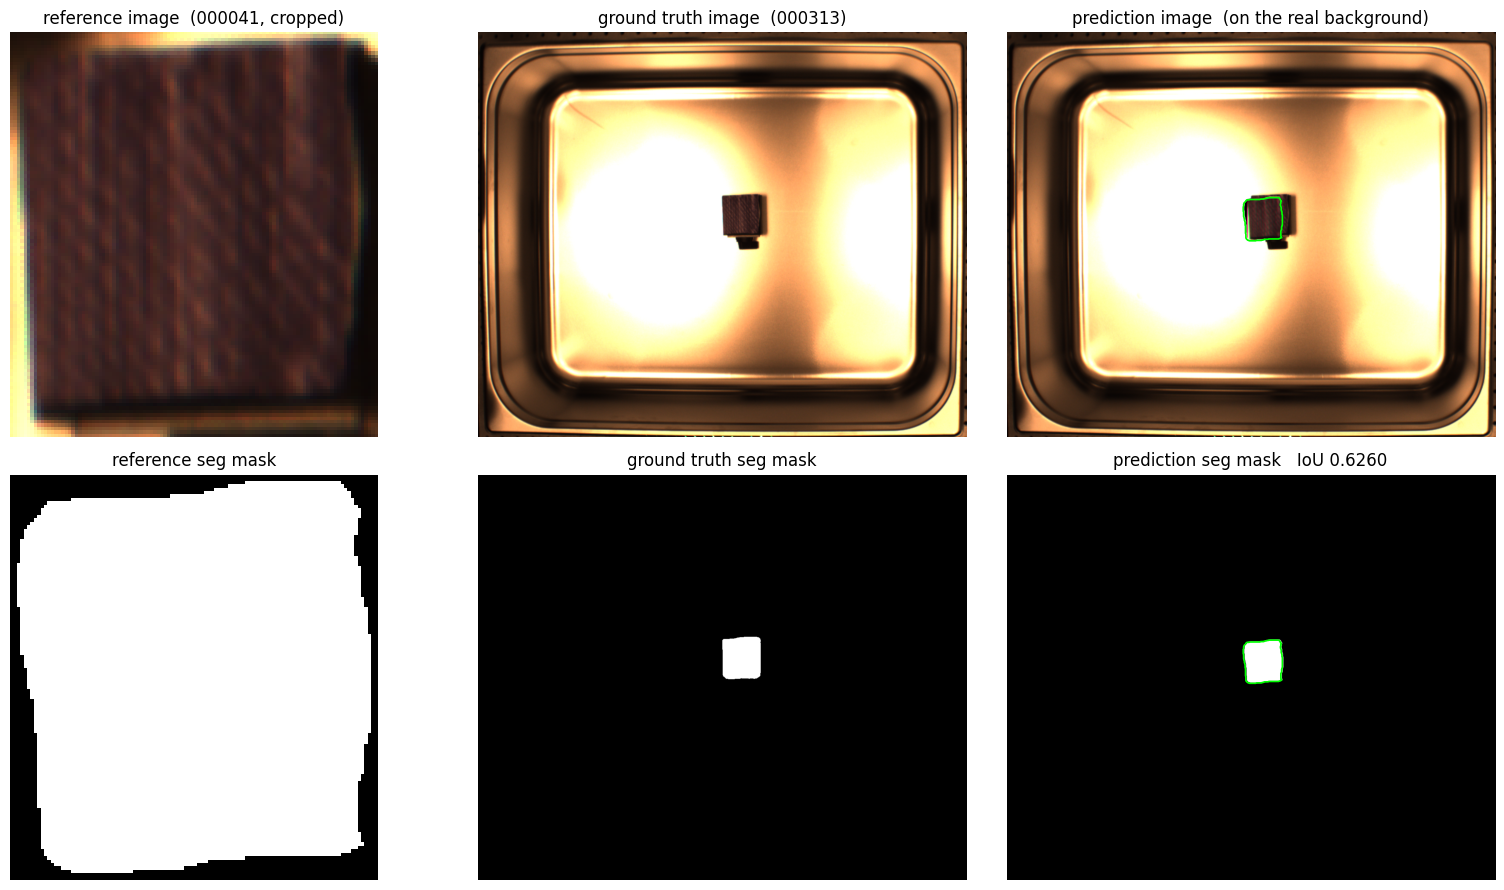

In [16]:
HEAD_DIR = Path("../runs/dec-d3-conv-v6/com_head")

def compare_heads(sample_id=None, head_dir=HEAD_DIR, show_best=True, split_mode="original"):
    """Run every saved head on one sample and rank them."""
    sample_id = sample_id or SAMPLE_ID
    # Default to the CLEAN checkpoints. The `_repart` ones were evaluated on a split that
    # re-partitions all one-cube data, which puts ~47% of the BACKBONE's training data in
    # the eval half -- every score there is ~1.7x too good.
    ckpts = [c for c in sorted(head_dir.glob("head_*.pt"))
             if split_mode is None or torch.load(c, map_location="cpu",
                                                 weights_only=False).get("split_mode") == split_mode]
    if not ckpts:
        raise FileNotFoundError(f"no head_*.pt in {head_dir} -- run scripts/com_head.sh first")

    truth_mask, truth_photo = load_mask(sample_id), load_photo(sample_id)
    true_row, true_col = center_of_mass(truth_mask)

    rows, best = [], None
    for cp in ckpts:
        head, ck = load_com_head(cp)
        ctx = context(ck)
        fft, _ = fetch(sample_id, ctx["loaders"])
        row, col, mask_pred = predict_com(fft, head, ctx["backbone"], ck)
        pred = predict(ref, row, col, out_shape=truth_mask.shape)
        r = {"name": cp.stem.replace("head_", ""), "eval_com_dist": ck["score"],
             "err_px": float(np.hypot(row - true_row, col - true_col)),
             "iou": iou(pred["mask"], truth_mask), "row": row, "col": col}
        rows.append(r)
        if best is None or r["eval_com_dist"] < best[0]["eval_com_dist"]:
            best = (r, pred)

    # the no-train incumbent, on the same sample: COM of the decoder's own mask
    _, ck0 = load_com_head(ckpts[0])
    ctx = context(ck0)
    fft, _ = fetch(sample_id, ctx["loaders"])
    _, _, dec_mask = predict_com(fft, load_com_head(ckpts[0])[0], ctx["backbone"], ck0)
    rn, cn = center_of_mass(torch.from_numpy(dec_mask), normalize=True)
    nt_row, nt_col = ds_norm_to_fullres(rn, cn, ck0["out_h"], ck0["out_w"])
    nt_pred = predict(ref, nt_row, nt_col, out_shape=truth_mask.shape)
    rows.append({"name": "no-train (decoder mask-COM)", "eval_com_dist": float("nan"),
                 "err_px": float(np.hypot(nt_row - true_row, nt_col - true_col)),
                 "iou": iou(nt_pred["mask"], truth_mask), "row": nt_row, "col": nt_col})

    rows.sort(key=lambda r: (np.isnan(r["eval_com_dist"]), r["eval_com_dist"]))
    print(f"\nsample {sample_id}   true (row, col) = ({true_row:.1f}, {true_col:.1f})\n")
    print(f"  {'head':32s} {'eval com-dist':>13s} {'err px':>8s} {'IoU':>8s}")
    for r in rows:
        d = "     --     " if np.isnan(r["eval_com_dist"]) else f"{r['eval_com_dist']:13.4f}"
        print(f"  {r['name']:32s} {d} {r['err_px']:8.1f} {r['iou']:8.4f}")
    print(f"\n  ceiling with a perfect centroid: 0.9161 (section 4)")

    if show_best:
        print(f"\nbest by eval metric: {best[0]['name']}")
        viz(best[1], ref, truth_photo, truth_mask, sample_id)
    return rows


compare_heads()           # <- uncomment once scripts/com_head.sh has run

### Error broken down by axis

One number hides which axis a head is failing on. The box is wider than it is tall
(1337 x 1110 px, a 30 x 21 grid), the lasers sample a 10 x 10 grid, and the speaker sits
on one side -- so there is no reason to expect row and column error to be equal.

Below, each head is scored over the **whole held-out split**, not a single sample, and the
error is reported three ways: row (y), column (x), and the euclidean combination. All in
full-resolution pixels, since normalised units make the two axes look comparable when they
are not -- the same normalised error is 1109 px vertically and 1336 px horizontally.

In [17]:
from com_head import build_cache, split_by_position, split_original, get_parser

def eval_all_heads(head_dir=HEAD_DIR, test_frac=0.25, seed=42, split_mode="original"):
    """Per-axis error for every saved head, over the entire held-out split.

    Reuses com_head.py's own cache and split so these numbers are directly comparable to
    what the sweep printed -- rebuilding either here would risk a different partition.
    """
    args = get_parser().parse_args([])
    args.test_frac, args.seed, args.split_mode = test_frac, seed, split_mode or "original"
    data = build_cache(args)
    tr, ev = (split_original(data) if args.split_mode == "original"
              else split_by_position(data, test_frac, seed))

    # full-resolution pixel scale: normalised (row, col) -> px
    H, W = 1110, 1337
    scale = np.array([H - 1, W - 1])

    def per_axis(pred_n, true_n):
        """(N,2) normalised -> mean |error| per axis, in px, plus the euclidean mean."""
        d = np.abs(pred_n - true_n) * scale
        eu = np.hypot(d[:, 0], d[:, 1])
        return d[:, 0].mean(), d[:, 1].mean(), eu.mean()

    true_n = ev["com"].numpy()
    rows = []

    # the incumbent: centroid of the decoder's own mask, no training
    r, c, e = per_axis(ev["mask_com"].numpy(), true_n)
    rows.append({"name": "no-train", "row_px": r, "col_px": c, "eu_px": e})

    for cp in sorted(head_dir.glob("head_*.pt")):
        ck = torch.load(cp, map_location="cpu", weights_only=False)
        if split_mode is not None and ck.get("split_mode") != split_mode:
            continue
        head = Head(ck["head"], ck["dec_shape"], ck["emb_dim"], ck["use_emb"],
                    ck["hidden"], ck["dropout"], (ck["out_h"], ck["out_w"]), ck["temperature"])
        head.load_state_dict(ck["state_dict"])
        head = head.to(DEVICE).eval()

        outs = []
        with torch.no_grad():
            for i in range(0, len(ev["com"]), 256):
                sl = slice(i, i + 256)
                o = head(ev["dec_feat"][sl].to(DEVICE), ev["emb"][sl].to(DEVICE))
                if ck["standardize"]:
                    o = o * ck["sigma"].to(DEVICE) + ck["mu"].to(DEVICE)
                outs.append(o.cpu())
        r, c, e = per_axis(torch.cat(outs).numpy(), true_n)
        rows.append({"name": cp.stem.replace("head_", ""), "row_px": r, "col_px": c, "eu_px": e})

    rows.sort(key=lambda x: x["eu_px"])
    print(f"eval split: {len(ev['com'])} samples / "
          f"{len(torch.unique(ev['position_id']))} positions\n")
    print(f"  {'head':26s} {'row (y) px':>11s} {'col (x) px':>11s} {'euclid px':>11s}")
    for x in rows:
        print(f"  {x['name']:26s} {x['row_px']:11.1f} {x['col_px']:11.1f} {x['eu_px']:11.1f}")
    return rows


head_errors = eval_all_heads()

reusing cache_e85c65e23b57b215.pt


eval split: 112 samples / 14 positions

  head                        row (y) px  col (x) px   euclid px
  softargmax_emb                    22.3        41.5        52.6
  softargmax_t02                    23.5        42.8        54.6
  softargmax_t05                    22.9        44.3        55.5
  softargmax                        23.8        43.6        55.7
  no-train                          49.7        54.6        81.9
  mlp_emb                          107.5        83.3       146.6
  mlp                              119.6        86.2       159.0
  conv                             119.1        90.2       164.4
  linear_emb                       126.9        89.9       168.4
  linear                           130.9       101.2       179.1
  conv_emb                         178.3       236.0       314.6


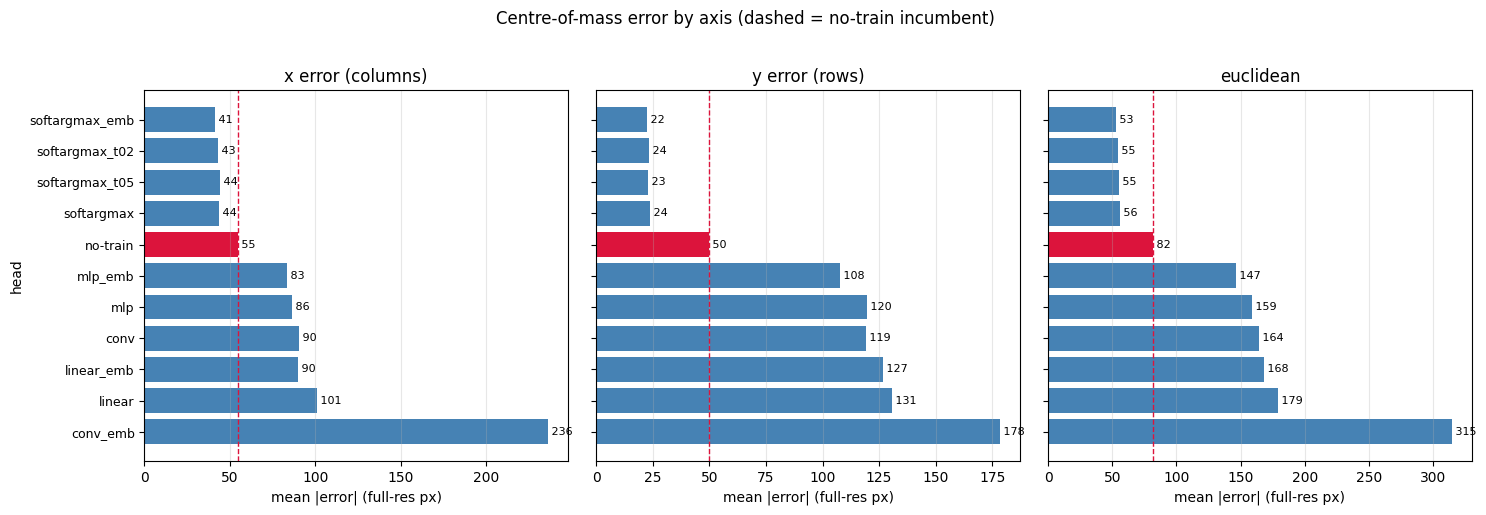

In [18]:
def plot_axis_errors(rows, figsize=(15, 5)):
    """Two bar charts -- x error and y error -- plus the combined, per head."""
    names = [r["name"] for r in rows]
    y_err = [r["row_px"] for r in rows]
    x_err = [r["col_px"] for r in rows]
    eu = [r["eu_px"] for r in rows]
    # the incumbent is the bar everything else has to clear, so colour it apart
    colors = ["crimson" if n == "no-train" else "steelblue" for n in names]

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    for ax, vals, title in zip(axes, [x_err, y_err, eu],
                               ["x error (columns)", "y error (rows)", "euclidean"]):
        ax.barh(range(len(names)), vals, color=colors)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("mean |error| (full-res px)")
        ax.set_title(title)
        ax.grid(axis="x", alpha=.3)
        nt = next(r for r in rows if r["name"] == "no-train")
        ax.axvline({"x error (columns)": nt["col_px"], "y error (rows)": nt["row_px"],
                    "euclidean": nt["eu_px"]}[title], ls="--", c="crimson", lw=1)
        for i, v in enumerate(vals):
            ax.text(v, i, f" {v:.0f}", va="center", fontsize=8)
    axes[0].set_ylabel("head")
    fig.suptitle("Centre-of-mass error by axis (dashed = no-train incumbent)", y=1.02)
    plt.tight_layout()
    return fig


plot_axis_errors(head_errors);

## Where this leaves us

**The geometric layer works.** Given a correct centroid, a single hardcoded scale and
theta=0 reproduce the true mask at the mean IoU printed above, across every position. The
`predict` function is the deployable piece: two numbers in, a placed object out.

**The residual is perspective, not model error.** Apparent cube size varies ~5% across the
box because the camera sees the sides of off-centre cubes -- and section 1 showed the same
effect leaking into theta, which drifts to -4.4 deg absorbing a shear it cannot represent.
A constant scale cannot track a spatial trend. In order of principle: (1) calibrate the plane and apply a homography,
(2) make scale a fixed function of (row, col), (3) leave it. **(3) is right for now** — the
gap to perfect placement is a few IoU points, and a vibration model that misses the centroid
by a few pixels will give up more than that.

**A caveat on the IoU.** It is measured against SAM3's masks, not truth, so part of the
residual is segmentation noise. Treat it as a floor on placement quality, not a ceiling.

**No vibration data touches this notebook.** That is deliberate: the layer is verified
against ground-truth centroids, so when the full pipeline underperforms the geometry is
already ruled out and the error is known to be in the sensing.

**Next.** Step 2 is predicting `(row, col)` from vibrations and feeding it to `predict`.
The first thing to build there is not a model but a **nearest-neighbour baseline** — match
vibration features to the closest recorded pose. That sets the ceiling for everything more
elaborate.

And carry both theta caveats forward: the cube is 4-fold symmetric, so theta is not a
learnable target against a mask loss; and what little angular signal exists here is
perspective, not rotation. Theta needs an asymmetric object *and* a rectified camera.

## The whole pipeline, one sample

Set `sample_id` and run. This is every stage end to end, with no ground truth used except
to score the result afterwards:

    FFT -> frozen backbone -> softargmax_emb head -> (row, col)
        -> pose matrix -> warp the reference template -> placed mask

The figure puts the predicted silhouette as a green outline on the real photo. Red is the
true outline, so where the two separate you are seeing the actual error -- part sensing
(the head's ~52 px mean on unseen positions), part the perspective residual from section 4
that no constant scale can absorb.

000177
head=softargmax use_emb=True eval com-dist 0.0418 (seed 43)
sample 000177   head softargmax_emb

                row (y)    col (x)
  predicted      338.58     634.74
  truth          324.15     514.86
  error          +14.43    +119.88   (120.7 px total)

  IoU(placed, truth) = 0.0000      ceiling with a perfect centroid: 0.9161


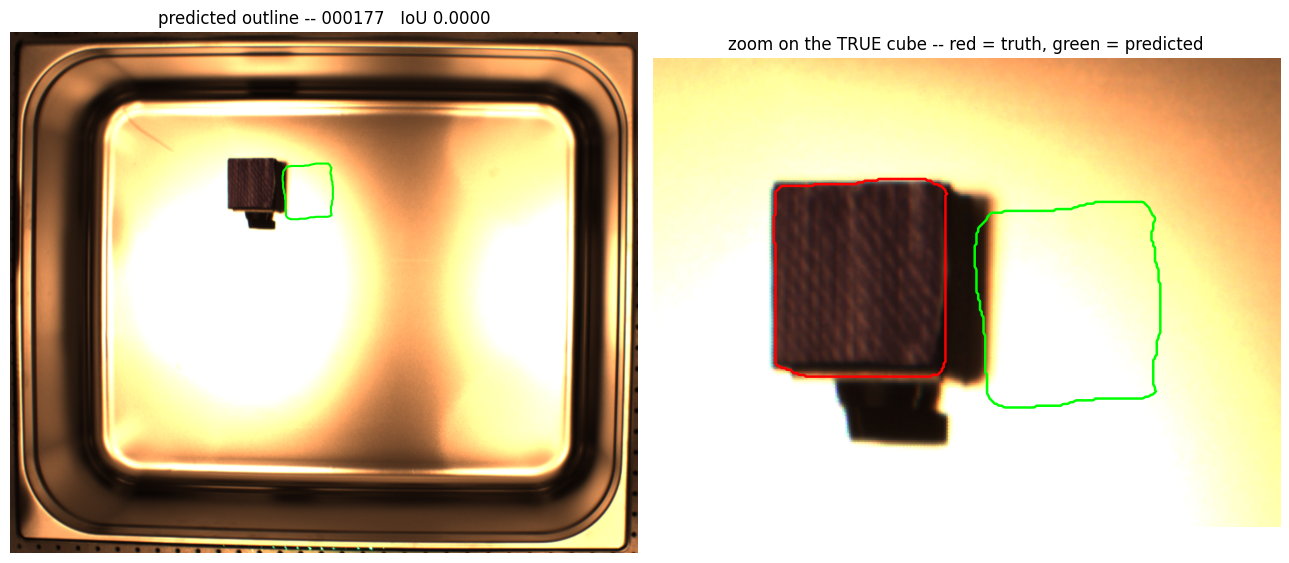

In [43]:
def place_from_vibrations(sample_id, ckpt_path=HEAD_DIR / "head_softargmax_emb.pt",
                          show=True, figsize=(13, 6)):
    """FFT -> (row, col) -> placed object. The one function that runs the whole thing."""
    head, ck = load_com_head(ckpt_path)
    ctx = context(ck)
    fft, _ = fetch(sample_id, ctx["loaders"])

    # ***** the prediction: two numbers, from vibrations alone *****
    row, col, _ = predict_com(fft, head, ctx["backbone"], ck)

    # ***** place the known template there *****
    truth_mask, truth_photo = load_mask(sample_id), load_photo(sample_id)
    pred = predict(ref, row, col, out_shape=truth_mask.shape)

    # ***** score it (the only place ground truth is touched) *****
    true_row, true_col = center_of_mass(truth_mask)
    d_row, d_col = row - true_row, col - true_col
    score = iou(pred["mask"], truth_mask)

    print(f"sample {sample_id}   head {ckpt_path.stem.replace('head_', '')}\n")
    print(f"  {'':10s} {'row (y)':>10s} {'col (x)':>10s}")
    print(f"  {'predicted':10s} {row:10.2f} {col:10.2f}")
    print(f"  {'truth':10s} {true_row:10.2f} {true_col:10.2f}")
    print(f"  {'error':10s} {d_row:+10.2f} {d_col:+10.2f}   "
          f"({np.hypot(d_row, d_col):.1f} px total)")
    print(f"\n  IoU(placed, truth) = {score:.4f}"
          f"      ceiling with a perfect centroid: 0.9161")

    if show:
        # window over truth AND prediction -- a badly-placed prediction would otherwise
        # sit outside a truth-only window and look absent rather than wrong
        rr, cc = np.nonzero(truth_mask)
        pr, pc = np.nonzero(pred["mask"] > 0.5)
        pad = 70
        r0 = max(min(rr.min(), pr.min() if len(pr) else rr.min()) - pad, 0)
        r1 = min(max(rr.max(), pr.max() if len(pr) else rr.max()) + pad, truth_mask.shape[0])
        c0 = max(min(cc.min(), pc.min() if len(pc) else cc.min()) - pad, 0)
        c1 = min(max(cc.max(), pc.max() if len(pc) else cc.max()) + pad, truth_mask.shape[1])
        win = (slice(r0, r1), slice(c0, c1))

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # the ORIGINAL photo with the predicted outline drawn on it -- not composite(),
        # which pastes the reference cube's pixels and so shows a second cube
        axes[0].imshow(truth_photo)
        axes[0].contour(pred["mask"], levels=[0.5], colors="lime", linewidths=1.5)
        axes[0].set_title(f"predicted outline -- {sample_id}   IoU {score:.4f}")

        axes[1].imshow(truth_photo[win])
        axes[1].contour(truth_mask[win].astype(float), levels=[0.5], colors="red", linewidths=1.8)
        axes[1].contour(pred["mask"][win], levels=[0.5], colors="lime", linewidths=1.8)
        axes[1].set_title("zoom on the TRUE cube -- red = truth, green = predicted")

        for a in axes: a.axis("off")
        plt.tight_layout()

#     return {"row": row, "col": col, "true_row": true_row, "true_col": true_col,
#             "d_row": d_row, "d_col": d_col, "iou": score, "pred": pred}

SAMPLE_ID = '000177'
print(SAMPLE_ID)
place_from_vibrations(SAMPLE_ID)

In [20]:
SAMPLE_ID

'000177'